<a href="https://colab.research.google.com/github/dr-koehler-ai/Heart-Failure-Clinical-Records-Dashboard/blob/main/Heart_Failure_Clinical_Records_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mortality Prediction in Patients with Heart Failure V2**

*Objective*

*   Predict Mortality using machine learning models

*Dataset*
*   299 patients
*   13 clinical features
*   binary outcome (target variable: death event)


*Workflow*
*   Data cleaning (V1)
*   EDA (V1)
*   Statistical Analysis (V1)
*   Logistic Regression (V1)
*   Machine Learning

*Clinical question*

Can clinical variables be used to predict mortality in heart failure patients, based on a simple baseline model?

In [4]:
# Heart Failure Clinical Records Dashboard (V2)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from statistics import mean, stdev
from math import sqrt

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Data modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from xgboost import XGBClassifier
from xgboost import plot_importance

# =========================
# 1. Dataset Download
# =========================

from google.colab import drive
drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/AI_Healthcare/Heart_Failure/heart_failure_clinical_records.csv")

data = pd.read_csv(dataset_path)

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


### Outcome limitation

The target variable indicates whether death occurred during follow-up, while follow-up duration varied between 4 and 285 days. Therefore, the model does not predict mortality within a fixed time horizon such as 30 or 90 days. The variable `time` was excluded from the predictors because follow-up duration is not available when making a prediction at baseline. A time-to-event analysis would address varying follow-up more appropriately, but this was outside the scope of this classification project.

In [43]:
data.head()

,Unnamed: 0,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Baseline model: **Gaussian Naive Bayes**

Gaussian Naive Bayes was used as a simple baseline model. The predictors include both continuous clinical measurements and binary variables. Therefore, the Gaussian distribution assumption is not fully met for every feature, and the model results should be interpreted as a baseline comparison rather than as the preferred final model.

              precision    recall  f1-score   support

           0       0.79      0.94      0.86        51
           1       0.79      0.46      0.58        24

    accuracy                           0.79        75
   macro avg       0.79      0.70      0.72        75
weighted avg       0.79      0.79      0.77        75



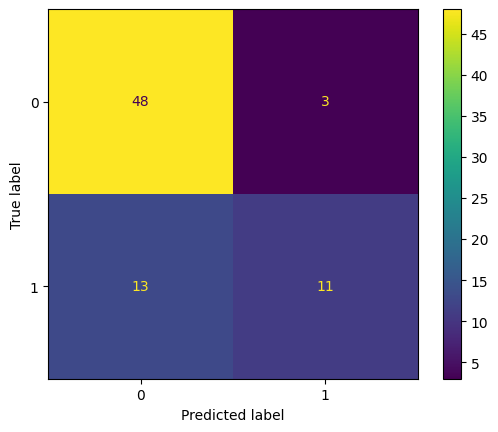

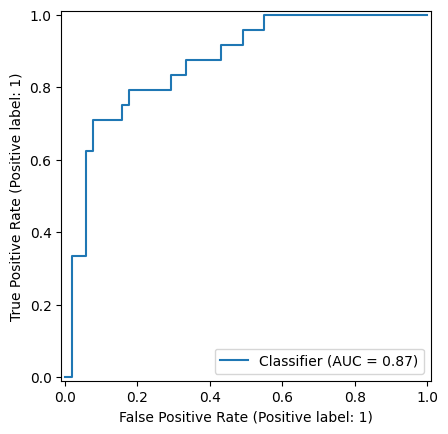

,proportion
death_event,
0,68.0
1,32.0


In [56]:
from sklearn.naive_bayes import GaussianNB

#Defining variables and target
y = data["death_event"]
X = data[['age','anaemia','creatinine_phosphokinase','diabetes','ejection_fraction','high_blood_pressure','platelets','serum_creatinine','serum_sodium','sex','smoking',
 'time']]

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Building the model
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gnb.classes_)
disp.plot()
plt.show()

# ROC Curve
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_gnb)
plt.show()

y_test.value_counts(normalize=True).mul(100)

**Decision Tree**

              precision    recall  f1-score   support

           0       0.85      0.88      0.87        51
           1       0.73      0.67      0.70        24

    accuracy                           0.81        75
   macro avg       0.79      0.77      0.78        75
weighted avg       0.81      0.81      0.81        75

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


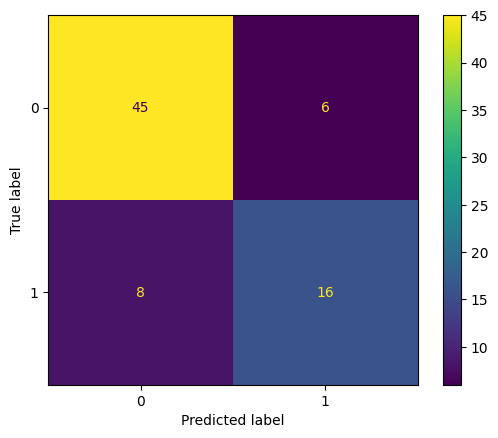

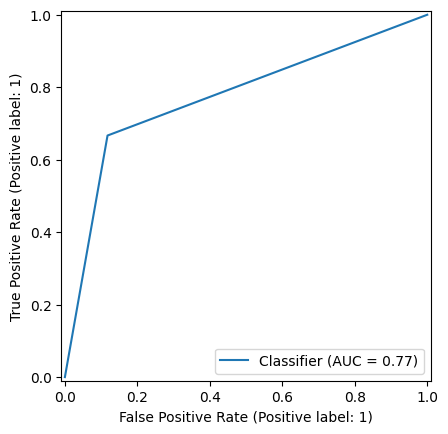

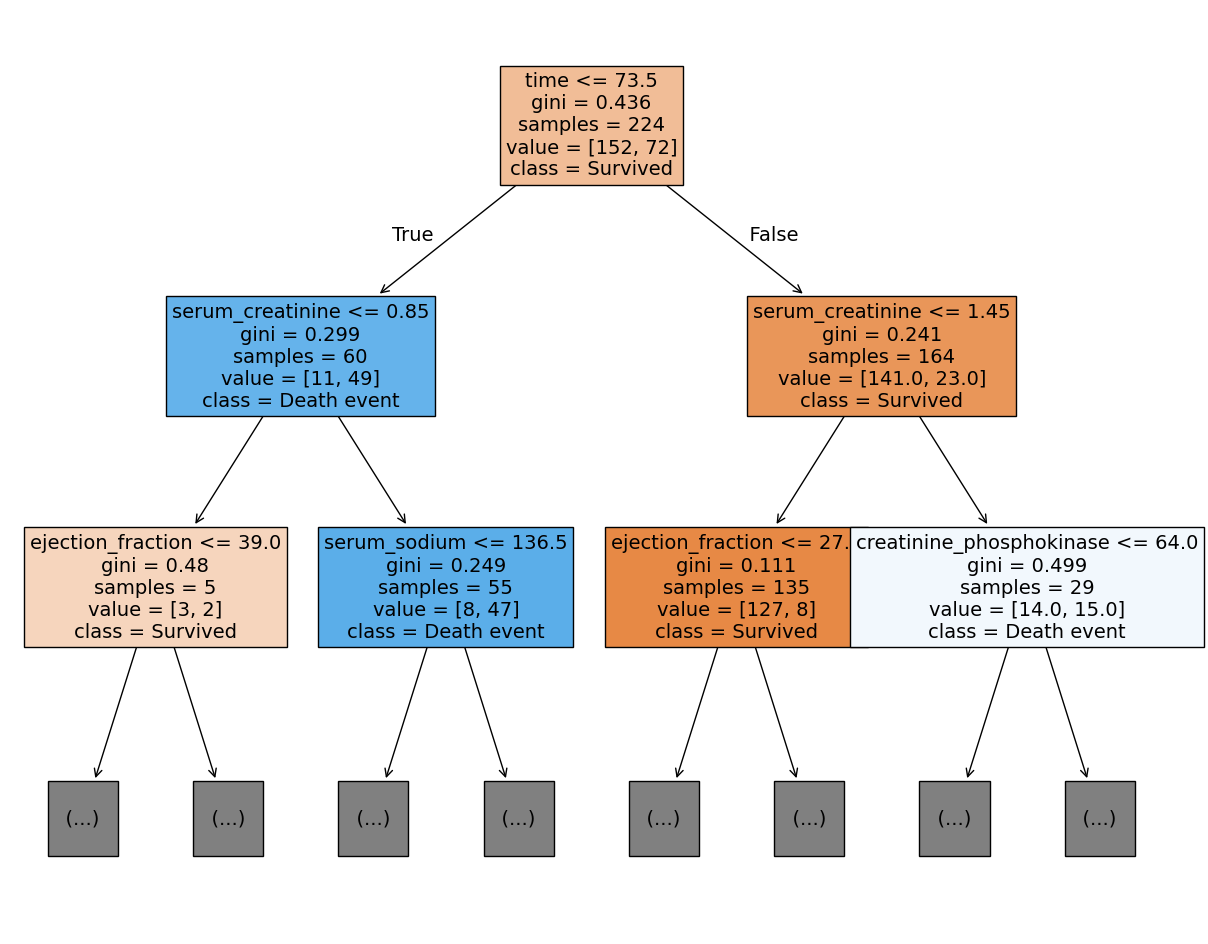

In [57]:
#Defining variables and target
y = data["death_event"]
X = data[['age','anaemia','creatinine_phosphokinase','diabetes','ejection_fraction','high_blood_pressure','platelets','serum_creatinine','serum_sodium','sex','smoking',
 'time']]

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Building the model
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_tree = decision_tree.predict(X_test)

# Classification Report & best parameters
print(classification_report(y_test, y_pred_tree))
print(decision_tree.get_params())

# Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=decision_tree.classes_)
disp_tree.plot()
plt.show()

# ROC Curve
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_tree)
plt.show()

# Plotting Decision Tree
plt.figure(figsize=(15,12))
plot_tree(decision_tree, max_depth=2, fontsize=14, class_names=["Survived", "Death event"], feature_names=X.columns, filled=True)
plt.show()


**GridSearchCV for tuning Decision Tree**

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        51
           1       0.60      0.62      0.61        24

    accuracy                           0.75        75
   macro avg       0.71      0.71      0.71        75
weighted avg       0.75      0.75      0.75        75

{'max_depth': 5, 'min_samples_leaf': 2}


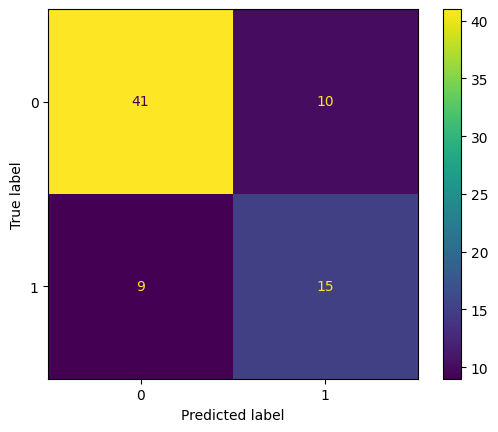

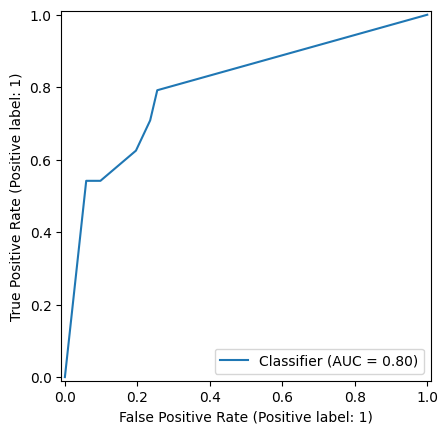

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        51
           1       0.60      0.62      0.61        24

    accuracy                           0.75        75
   macro avg       0.71      0.71      0.71        75
weighted avg       0.75      0.75      0.75        75



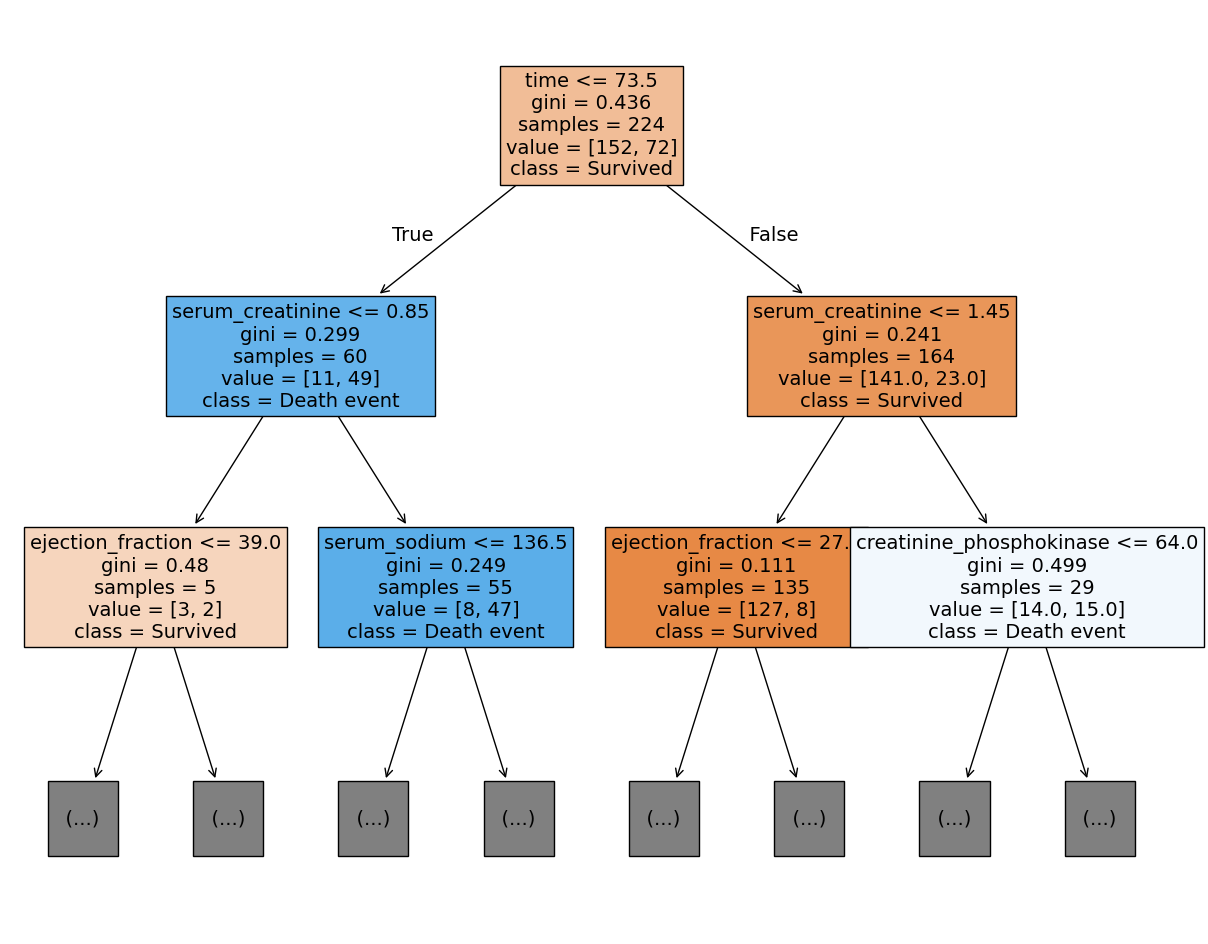

In [51]:
tree_para = {"max_depth": [4,5,6,7,8,9,10],
             "min_samples_leaf": [2,5,10]}
scoring = ["precision", "recall", "accuracy", "f1"]

#Building model
tuned_decision_tree = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV(tuned_decision_tree, tree_para, cv=5, scoring=scoring, refit="recall")
tree_cv.fit(X_train, y_train)
y_pred_tuned = tree_cv.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred_tuned))
print(tree_cv.best_params_)

# Confusion Matrix
cm_tree_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tree_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tree_tuned, display_labels=tree_cv.classes_)
disp_tree_tuned.plot()
plt.show()

# ROC Curve
y_prob_tuned = tree_cv.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_tuned)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_tuned))

# Plotting Decision Tree
plt.figure(figsize=(15,12))
plot_tree(tree_cv.best_estimator_, max_depth=2, fontsize=14, class_names=["Survived", "Death event"], feature_names=X.columns, filled=True)
plt.show()

**Random Forrest**

              precision    recall  f1-score   support

           0       0.85      0.90      0.88        51
           1       0.76      0.67      0.71        24

    accuracy                           0.83        75
   macro avg       0.81      0.78      0.79        75
weighted avg       0.82      0.83      0.82        75

{'max_depth': None, 'max_features': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}


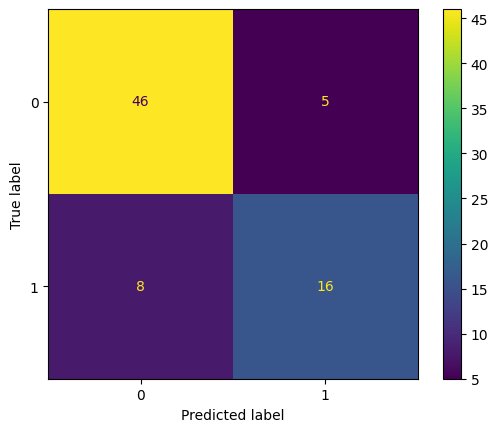

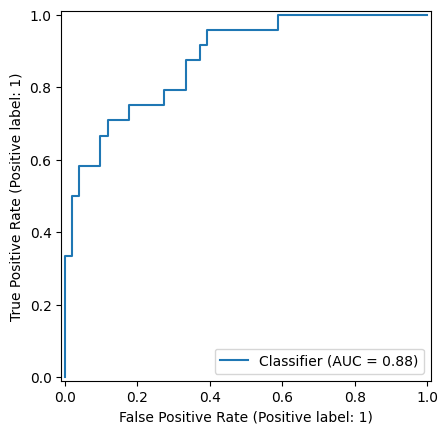

              precision    recall  f1-score   support

           0       0.85      0.90      0.88        51
           1       0.76      0.67      0.71        24

    accuracy                           0.83        75
   macro avg       0.81      0.78      0.79        75
weighted avg       0.82      0.83      0.82        75



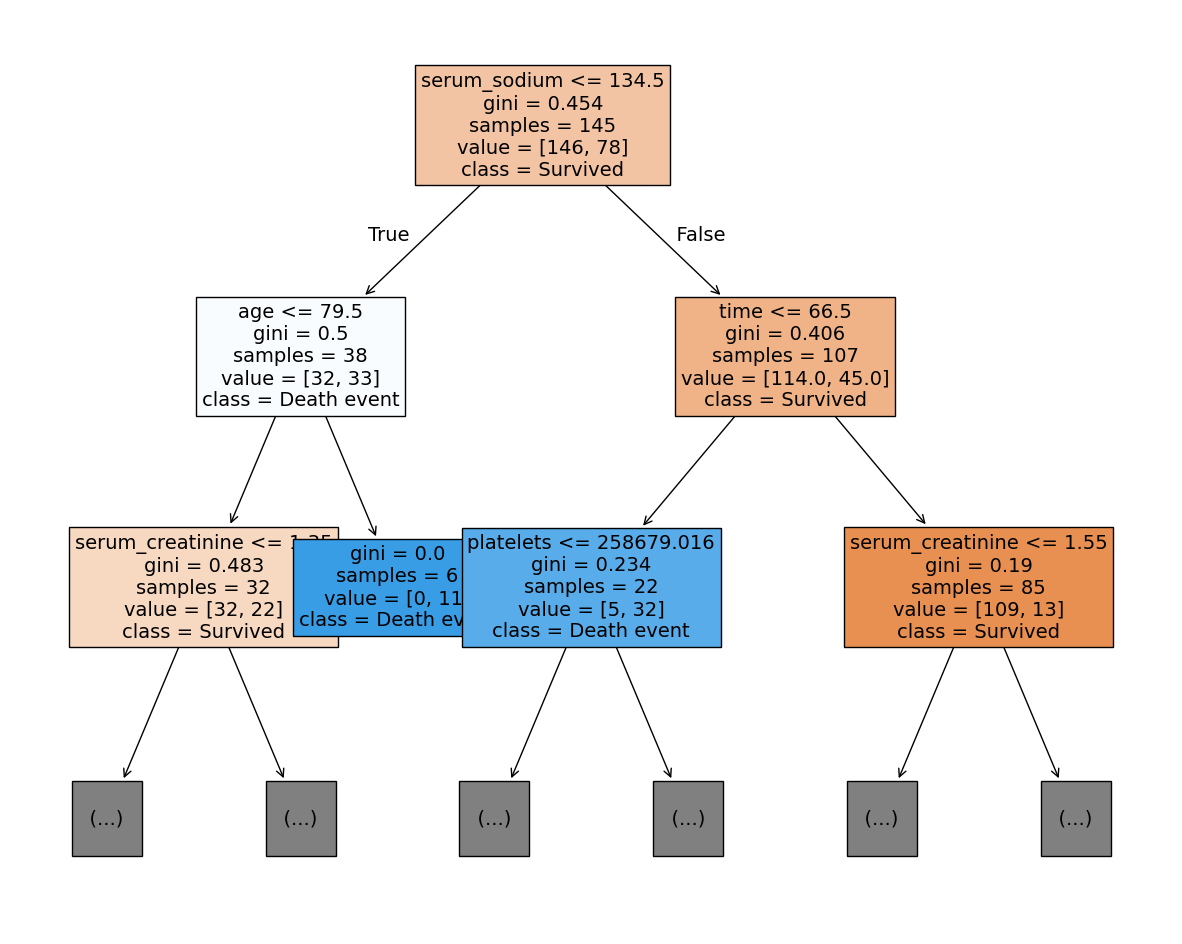

CPU times: user 6min 20s, sys: 965 ms, total: 6min 21s
Wall time: 6min 27s


In [55]:
%%time

forest_para = {"max_depth": [2,3,4,5,None],
               "min_samples_leaf": [1,2,3],
               "min_samples_split": [2,3,4],
               "max_features": [2,3,4],
               "n_estimators": [75,100, 125,150]}
scoring = ["precision", "recall", "accuracy", "f1"]

#Building model
rf = RandomForestClassifier(random_state=42)
rf_cv = GridSearchCV(rf, forest_para, cv=5, scoring=scoring, refit="recall")
rf_cv.fit(X_train, y_train)
y_pred_rf = rf_cv.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred_rf))
print(rf_cv.best_params_)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_cv.classes_)
disp_rf.plot()
plt.show()

# ROC Curve
y_prob_rf = rf_cv.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_rf))

# Plotting Decision Tree (first estimator from the Random Forest)
plt.figure(figsize=(15,12))
plot_tree(rf_cv.best_estimator_.estimators_[0], max_depth=2, fontsize=14, class_names=["Survived", "Death event"], feature_names=X.columns, filled=True)
plt.show()

### Exploratory threshold analysis

Thresholds were explored on the internal test set to illustrate the clinical trade-off between missed death events and false-positive alerts. A threshold around 0.35 appeared operationally plausible, but it was not independently validated and should not be described as an optimal clinical threshold. The default threshold of 0.50 remains the primary test-set evaluation.

   Threshold    Recall  Precision  False negatives  False positives
0       0.10  1.000000   0.320000                0               51
1       0.15  1.000000   0.320000                0               51
2       0.20  1.000000   0.320000                0               51
3       0.25  1.000000   0.320000                0               51
4       0.30  1.000000   0.324324                0               50
5       0.35  1.000000   0.387097                0               38
6       0.40  0.958333   0.522727                1               21
7       0.45  0.833333   0.606061                4               13
8       0.50  0.666667   0.727273                8                6
9       0.55  0.541667   0.812500               11                3
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        51
           1       0.73      0.67      0.70        24

    accuracy                           0.81        75
   macro avg       0.79      0.77 

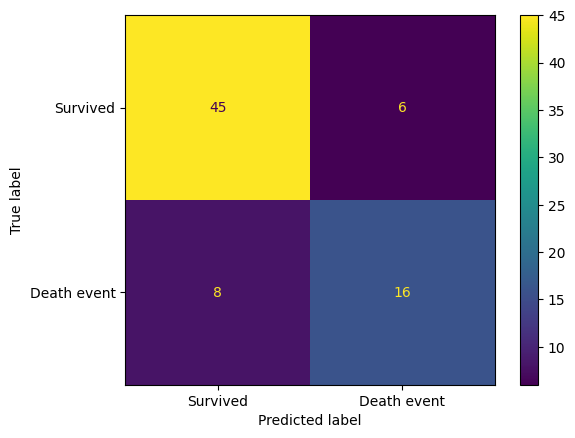

In [54]:
y_prob_rf = rf_cv.predict_proba(X_test)[:, 1]

threshold_results_rf = []

for threshold in np.arange(0.1, 0.6, 0.05):
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred_threshold, labels=[0, 1]
    ).ravel()

    threshold_results_rf.append({
        "Threshold": round(threshold, 2),
        "Recall": recall_score(y_test, y_pred_threshold),
        "Precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "False negatives": fn,
        "False positives": fp
    })

threshold_table_rf = pd.DataFrame(threshold_results_rf)
print(threshold_table_rf)

y_pred_rf_balanced = rf_cv.predict(X_test)

print(classification_report(y_test, y_pred_rf_balanced))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_balanced,
    display_labels=["Survived", "Death event"]
)
plt.show()

In [53]:
import pickle

path = "/content/drive/MyDrive/AI_Healthcare/Heart_Failure/"

with open(path + "rf_cv_model.pickle", "wb") as to_write:
    pickle.dump(rf_cv, to_write)

              precision    recall  f1-score   support

           0       0.85      0.90      0.88        51
           1       0.76      0.67      0.71        24

    accuracy                           0.83        75
   macro avg       0.81      0.78      0.79        75
weighted avg       0.82      0.83      0.82        75

{'max_depth': None, 'max_features': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}


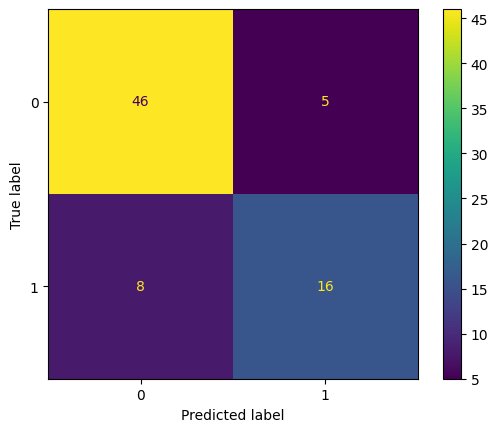

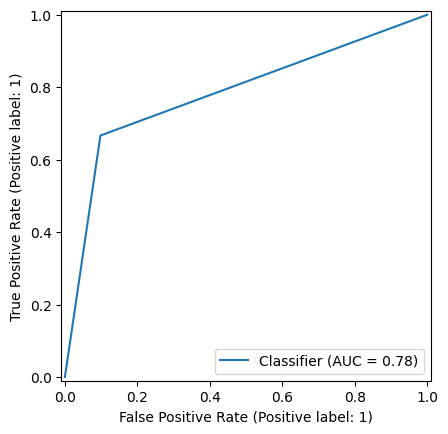

              precision    recall  f1-score   support

           0       0.85      0.90      0.88        51
           1       0.76      0.67      0.71        24

    accuracy                           0.83        75
   macro avg       0.81      0.78      0.79        75
weighted avg       0.82      0.83      0.82        75



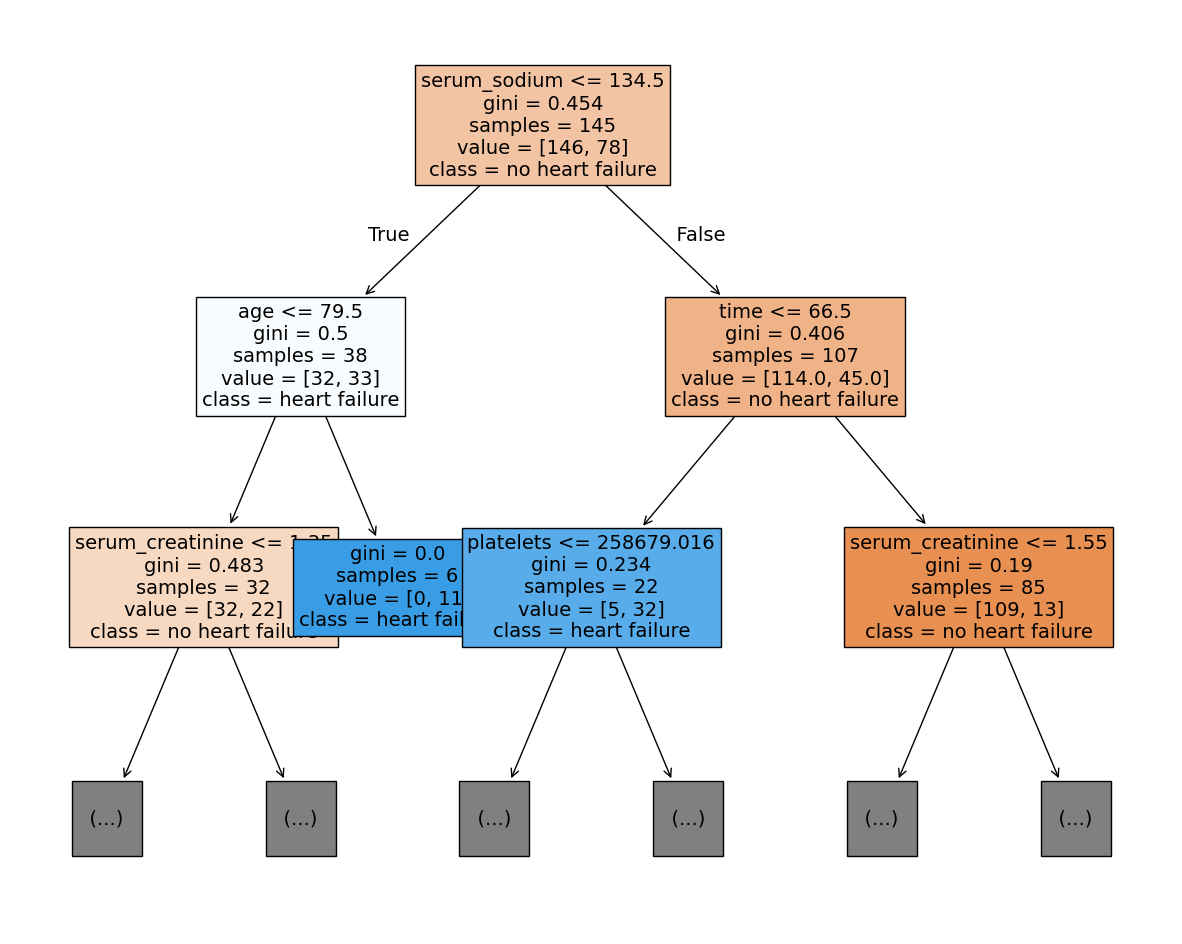

In [33]:
import pickle

path = "/content/drive/MyDrive/AI_Healthcare/Heart_Failure/"

with open(path + "rf_cv_model.pickle", "rb") as to_read:
    rf_cv = pickle.load(to_read)


y_pred_rf = rf_cv.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred_rf))
print(rf_cv.best_params_)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_cv.classes_)
disp_rf.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_rf))

# Plotting Decision Tree (first estimator from the Random Forest)
plt.figure(figsize=(15,12))
plot_tree(rf_cv.best_estimator_.estimators_[0], max_depth=2, fontsize=14, class_names=["Survived", "Death event"], feature_names=X.columns, filled=True)
plt.show()

**XGBoost**

              precision    recall  f1-score   support

           0       0.83      0.98      0.90        51
           1       0.93      0.58      0.72        24

    accuracy                           0.85        75
   macro avg       0.88      0.78      0.81        75
weighted avg       0.87      0.85      0.84        75

{'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 75}


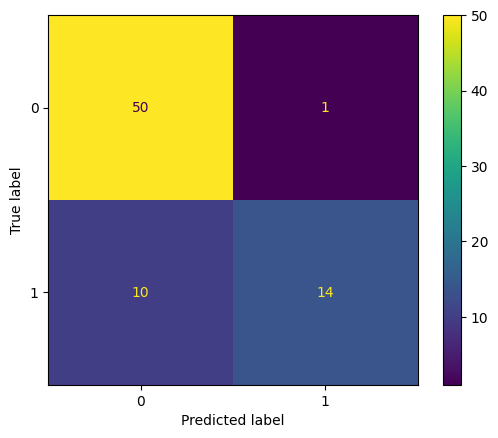

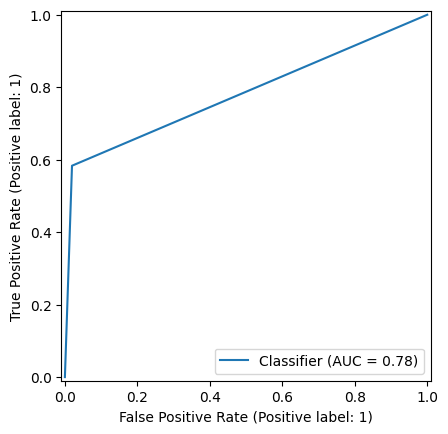

              precision    recall  f1-score   support

           0       0.83      0.98      0.90        51
           1       0.93      0.58      0.72        24

    accuracy                           0.85        75
   macro avg       0.88      0.78      0.81        75
weighted avg       0.87      0.85      0.84        75



<Figure size 1000x800 with 0 Axes>

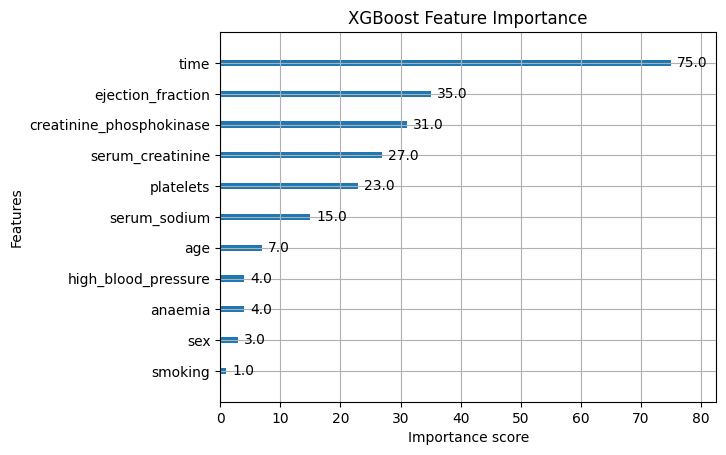

In [34]:
xgb_para = {"max_depth": [4,5,6,7,8],
               "min_child_weight": [1,2,3,4,5],
               "learning_rate": [0.1,0.2,0.3],
               "n_estimators": [75,100, 125]}
scoring = ["precision", "recall", "accuracy", "f1"]

#Building model
xgb = XGBClassifier(objective="binary:logistic",random_state=42)
xgb_cv = GridSearchCV(xgb, xgb_para, cv=5, scoring=scoring, refit="recall")
xgb_cv.fit(X_train, y_train) # Korrigiert: rf_cv.fit() zu xgb_cv.fit()
y_pred_xgb = xgb_cv.predict(X_test) # Korrigiert: rf_cv.predict() zu xgb_cv.predict()

# Classification Report
print(classification_report(y_test, y_pred_xgb))
print(xgb_cv.best_params_)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_cv.classes_)
disp_xgb.plot()
plt.show()

# ROC Curve
y_prob_xgb = xgb_cv.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_xgb))

# Plotting Feature Importance for XGBoost
plt.figure(figsize=(10, 8))
plot_importance(xgb_cv.best_estimator_)
plt.title("XGBoost Feature Importance")
plt.show()

In [35]:
import pickle

path = "/content/drive/MyDrive/AI_Healthcare/Heart_Failure/"

with open(path + "xgb_cv_model.pickle", "wb") as to_write:
    pickle.dump(xgb_cv, to_write)

              precision    recall  f1-score   support

           0       0.83      0.98      0.90        51
           1       0.93      0.58      0.72        24

    accuracy                           0.85        75
   macro avg       0.88      0.78      0.81        75
weighted avg       0.87      0.85      0.84        75

{'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 75}


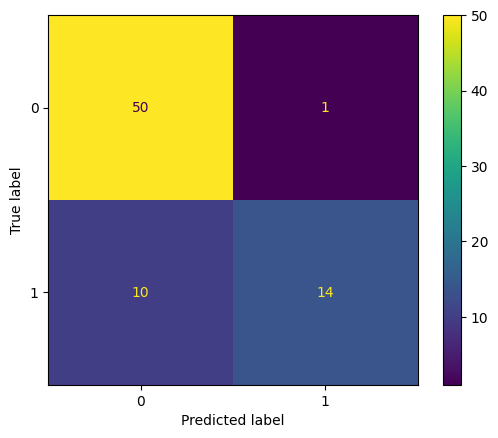

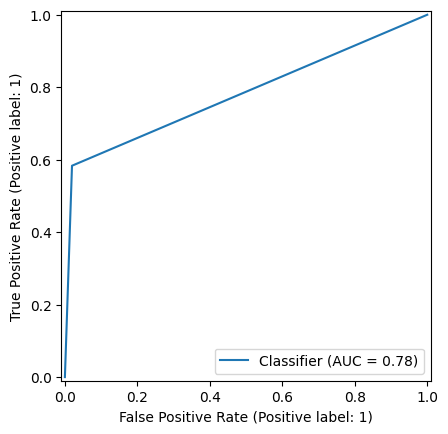

              precision    recall  f1-score   support

           0       0.83      0.98      0.90        51
           1       0.93      0.58      0.72        24

    accuracy                           0.85        75
   macro avg       0.88      0.78      0.81        75
weighted avg       0.87      0.85      0.84        75



<Figure size 1000x800 with 0 Axes>

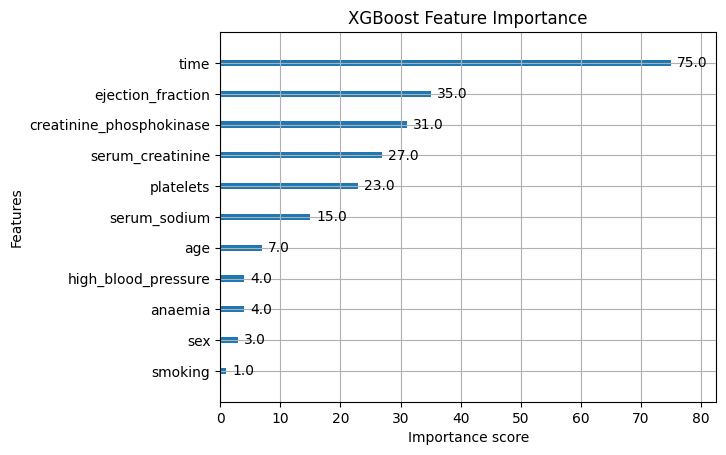

In [36]:
import pickle

path = "/content/drive/MyDrive/AI_Healthcare/Heart_Failure/"

with open(path + "xgb_cv_model.pickle", "rb") as to_read:
    xgb_cv = pickle.load(to_read)

y_pred_xgb = xgb_cv.predict(X_test) # Korrigiert: rf_cv.predict() zu xgb_cv.predict()

# Classification Report
print(classification_report(y_test, y_pred_xgb))
print(xgb_cv.best_params_)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_cv.classes_)
disp_xgb.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_xgb)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_xgb))

# Plotting Feature Importance for XGBoost
plt.figure(figsize=(10, 8))
plot_importance(xgb_cv.best_estimator_)
plt.title("XGBoost Feature Importance")
plt.show()

**Overview Models**

                 Model        F1    Recall  Accuracy  Precision
0          Gaussian NB  0.578947  0.458333  0.786667   0.785714
1        Decision Tree  0.695652  0.666667  0.813333   0.727273
2  Tuned Decision Tree  0.612245  0.625000  0.746667   0.600000
3        Random Forest  0.711111  0.666667  0.826667   0.761905
4              XGBoost  0.717949  0.583333  0.853333   0.933333
                 Model   ROC-AUC    PR-AUC
4              XGBoost  0.854575  0.817993
3        Random Forest  0.877451  0.812210
0          Gaussian NB  0.868464  0.720438
2  Tuned Decision Tree  0.802696  0.655101
1        Decision Tree  0.774510  0.591515
Random Forest Brier Score: 0.128
XGBoost Brier Score: 0.119


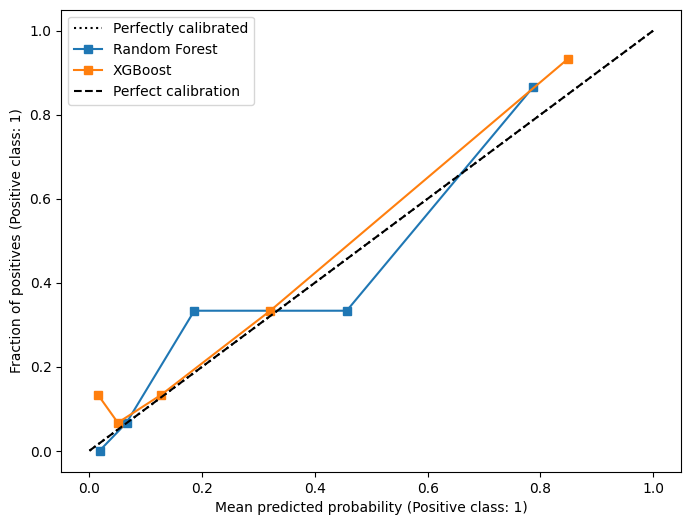

                 Model  Mean CV Recall  SD CV Recall  Mean CV Precision  \
0  Tuned Decision Tree        0.680952      0.081705           0.708627   
1        Random Forest        0.777143      0.114063           0.798397   
2              XGBoost        0.749524      0.097385           0.786071   

   SD CV Precision  
0         0.109927  
1         0.092776  
2         0.055056  


In [41]:
def make_results(model_name, model_object):
  cv_results = pd.DataFrame(model_object.cv_results_)
  best_estimator_results = cv_results.iloc[cv_results["mean_test_recall"].idxmax(),:]
  recall = best_estimator_results["mean_test_recall"]
  precision = best_estimator_results["mean_test_precision"]
  accuracy = best_estimator_results["mean_test_accuracy"]
  f1 = best_estimator_results["mean_test_f1"]

  table = pd.DataFrame({"Model": [model_name],
                        "F1": [f1],
                        "Recall": [recall],
                        "Accuracy": [accuracy],
                        "Precision": [precision]})
  return table

#results_gnb = pd.DataFrame({"Model": ["Gaussian NB"],
                            #"F1": [f1_score(y_test, y_pred)],
                            #"Recall": [recall_score(y_test, y_pred)],
                            #"Accuracy": [accuracy_score(y_test, y_pred)],
                            #"Precision": [precision_score(y_test, y_pred)]})

#results_tree = make_results("Decision Tree", tree_cv)
#results_tuned_tree = make_results("Tuned Decision Tree", tree_cv)
#results_forest = make_results("Random Forest", rf_cv)
#results_xgb = make_results("XGBoost", xgb_cv)

#results_overall_v1 = pd.concat([results_gnb, results_tree, results_tuned_tree, results_forest, results_xgb], axis=0)
#print(results_overall)

def make_test_results(model_name, y_true, y_pred):
    return pd.DataFrame({
        "Model": [model_name],
        "F1": [f1_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)]
    })

results_overall_v2 = pd.concat([
    make_test_results("Gaussian NB", y_test, y_pred),
    make_test_results("Decision Tree", y_test, y_pred_tree),
    make_test_results("Tuned Decision Tree", y_test, y_pred_tuned),
    make_test_results("Random Forest", y_test, y_pred_rf),
    make_test_results("XGBoost", y_test, y_pred_xgb)
], ignore_index=True)

print(results_overall_v2)

from sklearn.metrics import roc_auc_score, average_precision_score

model_probabilities = {
    "Gaussian NB": gnb.predict_proba(X_test)[:, 1],
    "Decision Tree": decision_tree.predict_proba(X_test)[:, 1],
    "Tuned Decision Tree": tree_cv.predict_proba(X_test)[:, 1],
    "Random Forest": rf_cv.predict_proba(X_test)[:, 1],
    "XGBoost": xgb_cv.predict_proba(X_test)[:, 1]
}

auc_results = []

for model_name, probabilities in model_probabilities.items():
    auc_results.append({
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities)
    })

auc_table = pd.DataFrame(auc_results).sort_values(
    "PR-AUC", ascending=False
)

print(auc_table)

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(8, 6))

for model_name in ["Random Forest", "XGBoost"]:
    probabilities = model_probabilities[model_name]

    CalibrationDisplay.from_predictions(
        y_test,
        probabilities,
        n_bins=5,
        strategy="quantile",
        name=model_name,
        ax=ax
    )

    print(
        model_name,
        "Brier Score:",
        round(brier_score_loss(y_test, probabilities), 3)
    )

ax.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
ax.legend()
plt.show()

def best_cv_summary(model_name, grid_search):
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = grid_search.best_index_

    return pd.DataFrame({
        "Model": [model_name],
        "Mean CV Recall": [
            results.loc[best_index, "mean_test_recall"]
        ],
        "SD CV Recall": [
            results.loc[best_index, "std_test_recall"]
        ],
        "Mean CV Precision": [
            results.loc[best_index, "mean_test_precision"]
        ],
        "SD CV Precision": [
            results.loc[best_index, "std_test_precision"]
        ]
    })

cv_summary = pd.concat([
    best_cv_summary("Tuned Decision Tree", tree_cv),
    best_cv_summary("Random Forest", rf_cv),
    best_cv_summary("XGBoost", xgb_cv)
], ignore_index=True)

print(cv_summary)

### Validation limitations

Model development and hyperparameter selection were performed using cross-validation within the training set. Final performance was evaluated on a held-out internal test set. No external validation was performed. Therefore, the results demonstrate internal performance only and should not be interpreted as evidence of generalizability to other hospitals or patient populations.

